Text(0.5, 1.0, 'Random Classification Data with 2 classes')

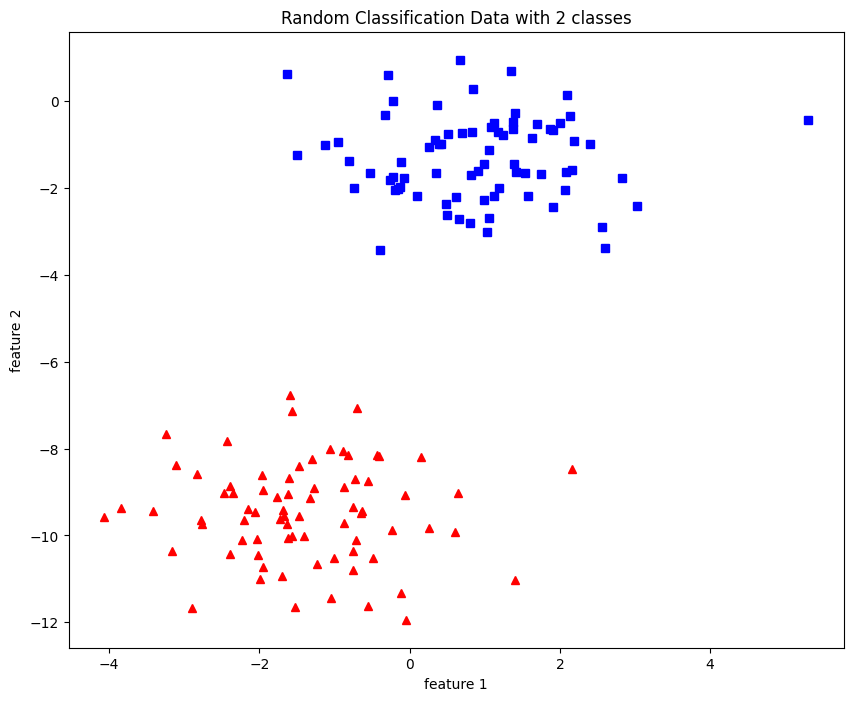

In [2]:
from sklearn import datasets
import matplotlib.pyplot as plt
X, y = datasets.make_blobs (n_samples=150, n_features=2,
centers=2, cluster_std=1.05,

random_state=2)

#Plotting
fig = plt.figure(figsize=(10,8))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')

In [3]:
def acti_func(z):
  if (z>0):
    return 1
  return 0

In [4]:
import numpy as np
def perceptron(X, y, lr, epochs):
    # X --> Inputs.
    # y --> labels/target.
    # lr --> learning rate.
    # epochs --> Number of iterations.
    # m-> number of training examples
    # n-> number of features
    m, n = X.shape
    # Initializing parameters(theta) to zeros.
    # +1 in n+1 for the bias term.
    w = np.zeros((n+1,1))
    # Empty list to store how many examples were
    # misclassified at every iteration.
    n_miss_list = []
    # Training.
    for epoch in range(epochs):
        # variable to store #misclassified.
        n_miss = 0
        # looping for every example.
        for idx, x_i in enumerate(X):
            # Insering 1 for bias, X0 = 1.
            x_i = np.insert(x_i, 0, 1).reshape(-1,1)
            # Calculating prediction/hypothesis.
            y_hat = acti_func(np.dot(x_i.T, w))
            # Updating if the example is misclassified.
            if (np.squeeze(y_hat) - y[idx]) != 0:
              w+= lr*(y[idx]-y_hat)*x_i
              n_miss+=1
            # Incrementing by 1.
            # Appending number of misclassified examples
            # at every iteration.
        n_miss_list.append(n_miss)
    return w, n_miss_list

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(X, w):
    # X --> Inputs
    # w --> parameters

    # Extract weights
    w0, w1, w2 = w[0], w[1], w[2]

    # Calculate slope (m) and intercept (c)
    m = -w1 / w2
    c = -w0 / w2

    # Generate x1 values (min and max of the first feature)
    x1 = np.array([min(X[:, 0]), max(X[:, 0])])

    # Calculate x2 values using the line equation
    x2 = m * x1 + c

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=100, edgecolors='k')
    plt.plot(x1, x2, 'k-', label="Decision Boundary")
    plt.xlabel('Feature 1 (x1)')
    plt.ylabel('Feature 2 (x2)')
    plt.title('Perceptron Decision Boundary')
    plt.legend()
    plt.grid(True)
    plt.show()

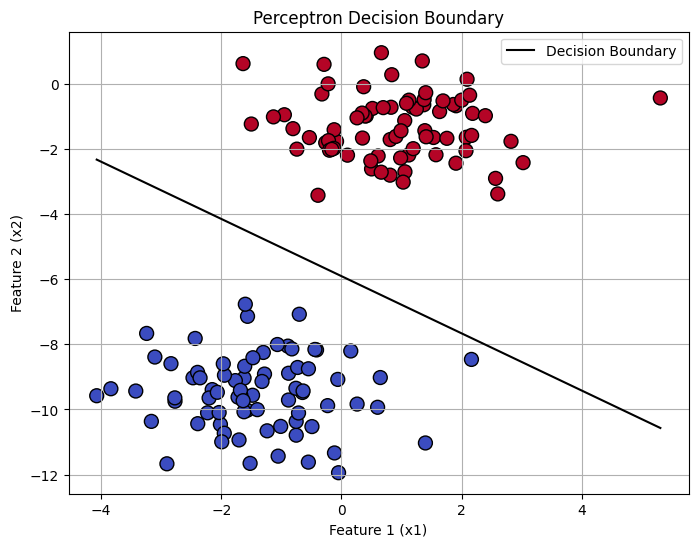

In [19]:
w, n_miss_list = perceptron(X, y, 0.01, 50)
plot_decision_boundary(X, w)